<a href="https://colab.research.google.com/github/prameela-rani-patnaik/Student_Performance_Analysis/blob/main/M3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pandas numpy matplotlib scikit-learn joblib

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv(r"student_exam_performance_dataset.csv")

In [4]:
df.shape

(10000, 23)

In [8]:
# Create target
df['pass_fail'] = (df['math_score'] >= 40).astype(int)
X = df[[
    'study_hours_per_day',
    'attendance_rate',
    'sleep_hours',
    'previous_gpa'
]]
y = df['pass_fail']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

from sklearn.linear_model import LogisticRegression
model = LogisticRegression()

model.fit(X_train_scaled, y_train)

LogisticRegression()

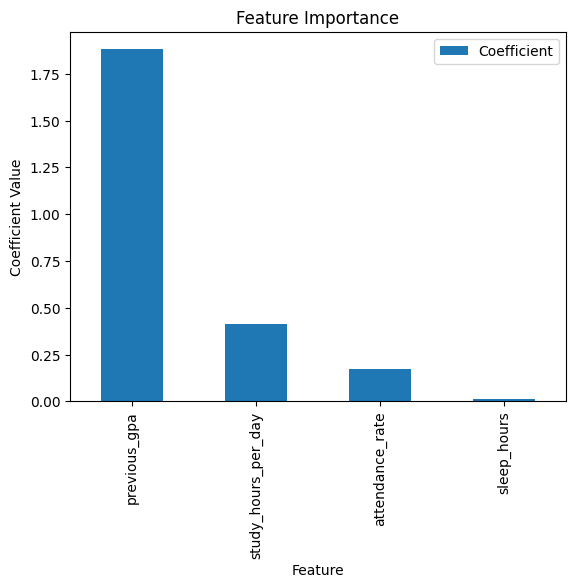

In [20]:
import pandas as pd

importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

importance = importance.sort_values(
    by='Coefficient',
    ascending=False
)

importance.plot(
    x='Feature',
    y='Coefficient',
    kind='bar'
)

plt.title('Feature Importance')
plt.ylabel('Coefficient Value')

plt.show()

In [22]:
new_data = pd.DataFrame({
    'study_hours_per_day': [6],
    'attendance_rate':[45],
    'sleep_hours':[6],
    'previous_gpa':[9.8]
})

new_data_scaled = scaler.transform(new_data)

print(model.predict(new_data_scaled))
print(model.predict_proba(new_data_scaled))

[1]
[[1.76525461e-13 1.00000000e+00]]


In [13]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8346666666666667


In [14]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[ 451  319]
 [ 177 2053]]


In [16]:
from sklearn.metrics import f1_score

f1 = f1_score(y_test, y_pred)

print("F1 Score:", f1)

F1 Score: 0.8922207735767058
